# Plotter hTPC

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

In [14]:
FIG_SINGLE = (3.34, 2.5)
FIG_DOUBLE = (6.69, 3.5)

plt.rcParams.update({
    # Figure
    "figure.figsize": FIG_SINGLE,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    
    # Colours
    'image.cmap': 'inferno',

    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,

    # Axes labels and titles
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "axes.labelpad": 3,
    "axes.titlepad": 4,

    # Ticks
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.pad": 2,
    "ytick.major.pad": 2,

    # Lines
    "lines.linewidth": 1.0,
    "lines.markersize": 3,

    # Axes appearance
    "axes.linewidth": 0.6,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",

    # Tick colour
    "xtick.color": "black",
    "ytick.color": "black",

    # Legend
    "legend.fontsize": 6,
    "legend.frameon": False,
    "legend.handlelength": 1.2,
    "legend.handletextpad": 0.4,
    "legend.borderaxespad": 0.4,

    # Grid
    "axes.grid": False,
    "grid.color": "0.85",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.8,

    # Export fonts as editable text in vector files
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

isotope_dict = {
    "U238": {
        "tex": r"$^{238}$U",
        "color": "royalblue",
    },
    "Th232": {
        "tex": r"$^{232}$Th",
        "color": "darkorange",
    },
    "Co60": {
        "tex": r"$^{60}$Co",
        "color": "crimson",
    },
    "Cs137": {
        "tex": r"$^{137}$Cs",
        "color": "purple",
    },
    "K40": {
        "tex": r"$^{40}$K",
        "color": "goldenrod",
    },
    "Kr85": {
        "tex": r"$^{85}$Kr",
        "color": "deepskyblue",
    },
    "Ra222": {
        "tex": r"$^{222}$Ra",
        "color": "saddlebrown",
    },
    "SN": {
        "tex": r"Solar",
        "color": "seagreen",
    },
    "Xe136": {
        "tex": r"$^{136}$Xe",
        "color": "black",
    },
    "Xe124": {
        "tex": r"$^{124}$Xe",
        "color": "pink",
    }
}

### Nadav: Low Energy Spectrum (materials + intrinsics)

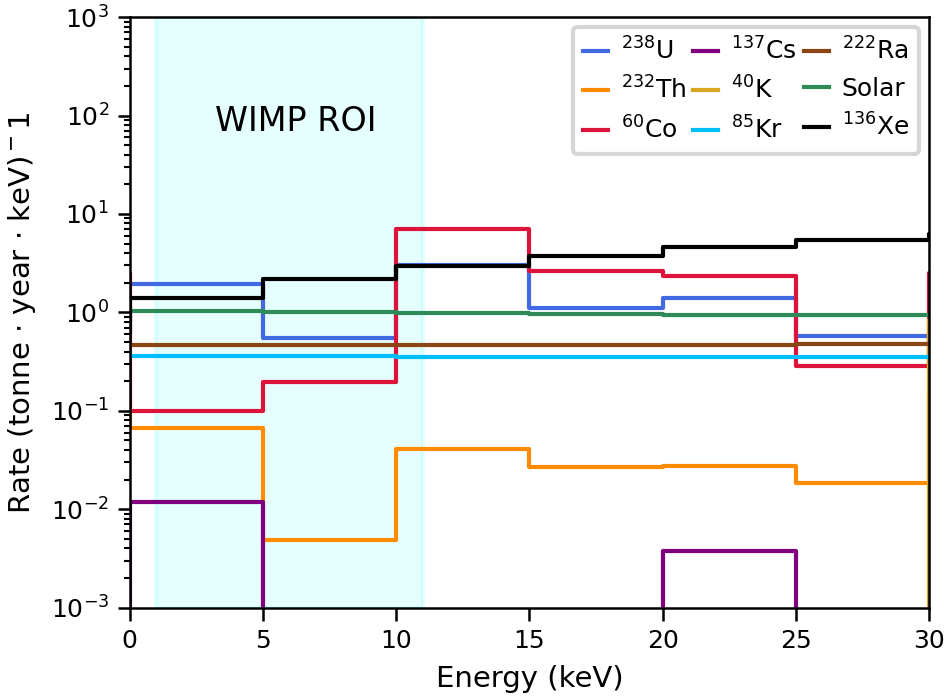

In [25]:
low_e_dict = np.load(PROJECT_ROOT / "common_plots" / "data" / "low_e.npz")

e_edges  = low_e_dict["e_edges"]
hist_arr = low_e_dict["hist_arr"]
isotope_list = low_e_dict["isotope_list"]

fig, ax = plt.subplots(figsize=FIG_SINGLE)
for idx, hist in enumerate(hist_arr):
    ax.step(e_edges[:-1], hist, label = isotope_dict[isotope_list[idx]]["tex"], color = isotope_dict[isotope_list[idx]]["color"])

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(rf"Rate (tonne $\cdot$ year $\cdot$ keV)$^{-1}$")
ax.set_yscale("log")
ax.set_xlim(0,30)
ax.set_ylim(1e-3, 1e3)

ax.axvspan(1, 11, alpha=0.1, color='cyan')
ax.text(3.2, 70, r'WIMP ROI', fontsize=8)

ax.legend(
loc="upper right",
ncol=3,
frameon=True,
fontsize=6,
columnspacing=0.3,
handlelength=1,
handletextpad=0.5,
borderpad=0.4,
)
plt.tight_layout();